# Análise de vendas

Análise da base do desafio usando pandas e matplotlib.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
vendas = pd.read_excel("../Base-Dados-Desafio-500k.xlsx", sheet_name="VENDAS")
produtos = pd.read_excel("../Base-Dados-Desafio-500k.xlsx", sheet_name="PRODUTOS")


In [3]:
vendas.head()


,CLIENTE,IDADE,ESTADO,PRODUTO,QUANTIDADE_VENDIDA,PREÇO_UNITARIO,DATA
0,9010.0,72.0,SANTA CATARINA,E,243,50,2024-10-26
1,63611.0,46.0,PARANÁ,B,320,15,2024-12-27
2,56708.0,67.0,BAHIA,D,143,30,2023-06-30
3,3924.0,46.0,SÃO PAULO,B,295,15,2025-06-02
4,47317.0,53.0,RIO DE JANEIRO,C,203,45,2025-02-15


In [4]:
produtos


,PRODUTO,CATEGORIA
0,A,MAQUINA DE CORTAR GRAMA
1,B,MANGUEIRAS
2,C,UTILIDADES DOMÉSTICAS
3,D,LIMPEZA
4,E,JARDINAGEM


## olhando a base


In [5]:
vendas.shape


(500000, 7)

In [6]:
vendas.info()


<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   CLIENTE             499484 non-null  float64       
 1   IDADE               499850 non-null  float64       
 2   ESTADO              499630 non-null  str           
 3   PRODUTO             499452 non-null  str           
 4   QUANTIDADE_VENDIDA  500000 non-null  int64         
 5   PREÇO_UNITARIO      500000 non-null  int64         
 6   DATA                500000 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(2), int64(2), str(2)
memory usage: 26.7 MB


In [7]:
vendas.isnull().sum()


CLIENTE               516
IDADE                 150
ESTADO                370
PRODUTO               548
QUANTIDADE_VENDIDA      0
PREÇO_UNITARIO          0
DATA                    0
dtype: int64

In [8]:
vendas.duplicated().sum()


np.int64(3)

In [9]:
vendas.describe()


,CLIENTE,IDADE,QUANTIDADE_VENDIDA,PREÇO_UNITARIO,DATA
count,499484.000000,499850.000000,500000.000000,500000.000000,500000
mean,40015.170138,39.183431,185.928544,32.980870,2023-07-02 21:50:55.795200
min,1.000000,18.000000,26.000000,0.000000,2021-01-01 00:00:00
25%,19993.000000,31.000000,147.000000,25.000000,2022-04-03 00:00:00
50%,40052.500000,39.000000,187.000000,30.000000,2023-07-02 00:00:00
75%,59981.000000,47.000000,231.000000,45.000000,2024-10-01 00:00:00
max,80000.000000,80.000000,432.000000,50.000000,2025-12-31 00:00:00
std,23088.348541,11.560814,80.424516,12.914743,NaN


## tratamento


In [10]:
# removendo linhas repetidas
vendas = vendas.drop_duplicates()


In [11]:
# ajustando os tipos
vendas["DATA"] = pd.to_datetime(vendas["DATA"], errors="coerce")
vendas["CLIENTE"] = pd.to_numeric(vendas["CLIENTE"], errors="coerce")
vendas["IDADE"] = pd.to_numeric(vendas["IDADE"], errors="coerce")
vendas["QUANTIDADE_VENDIDA"] = pd.to_numeric(vendas["QUANTIDADE_VENDIDA"], errors="coerce")
vendas["PREÇO_UNITARIO"] = pd.to_numeric(vendas["PREÇO_UNITARIO"], errors="coerce")


In [12]:
# deixando os textos no mesmo padrão
vendas["ESTADO"] = vendas["ESTADO"].str.strip().str.upper()
vendas["PRODUTO"] = vendas["PRODUTO"].str.strip().str.upper()

produtos["PRODUTO"] = produtos["PRODUTO"].str.strip().str.upper()


In [13]:
# trazendo a categoria da outra aba
vendas = vendas.merge(produtos, on="PRODUTO", how="left")

vendas.head()


,CLIENTE,IDADE,ESTADO,PRODUTO,QUANTIDADE_VENDIDA,PREÇO_UNITARIO,DATA,CATEGORIA
0,9010.0,72.0,SANTA CATARINA,E,243,50,2024-10-26,JARDINAGEM
1,63611.0,46.0,PARANÁ,B,320,15,2024-12-27,MANGUEIRAS
2,56708.0,67.0,BAHIA,D,143,30,2023-06-30,LIMPEZA
3,3924.0,46.0,SÃO PAULO,B,295,15,2025-06-02,MANGUEIRAS
4,47317.0,53.0,RIO DE JANEIRO,C,203,45,2025-02-15,UTILIDADES DOMÉSTICAS


In [14]:
vendas.isnull().sum()


CLIENTE               516
IDADE                 150
ESTADO                370
PRODUTO               548
QUANTIDADE_VENDIDA      0
PREÇO_UNITARIO          0
DATA                    0
CATEGORIA             548
dtype: int64

In [15]:
# removendo dados que não ajudam nas análises
vendas = vendas.dropna(subset=["CLIENTE", "IDADE", "ESTADO", "PRODUTO", "CATEGORIA", "DATA"])

vendas = vendas[vendas["IDADE"] >= 18]
vendas = vendas[vendas["IDADE"] <= 80]

vendas = vendas[vendas["QUANTIDADE_VENDIDA"] > 0]
vendas = vendas[vendas["PREÇO_UNITARIO"] > 0]

vendas.shape


(498413, 8)

In [16]:
# valor total da venda
vendas["VALOR_TOTAL"] = vendas["QUANTIDADE_VENDIDA"] * vendas["PREÇO_UNITARIO"]

vendas.head()


,CLIENTE,IDADE,ESTADO,PRODUTO,QUANTIDADE_VENDIDA,PREÇO_UNITARIO,DATA,CATEGORIA,VALOR_TOTAL
0,9010.0,72.0,SANTA CATARINA,E,243,50,2024-10-26,JARDINAGEM,12150
1,63611.0,46.0,PARANÁ,B,320,15,2024-12-27,MANGUEIRAS,4800
2,56708.0,67.0,BAHIA,D,143,30,2023-06-30,LIMPEZA,4290
3,3924.0,46.0,SÃO PAULO,B,295,15,2025-06-02,MANGUEIRAS,4425
4,47317.0,53.0,RIO DE JANEIRO,C,203,45,2025-02-15,UTILIDADES DOMÉSTICAS,9135


## perfil dos clientes


In [17]:
vendas["IDADE"].mean()


np.float64(39.18345227752888)

In [18]:
vendas["IDADE"].median()


np.float64(39.0)

In [19]:
# separando por faixa de idade
vendas["FAIXA_ETARIA"] = pd.cut(
    vendas["IDADE"],
    bins=[17, 24, 34, 44, 54, 64, 100],
    labels=["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]
)

vendas["FAIXA_ETARIA"].value_counts().sort_index()


FAIXA_ETARIA
18-24     56642
25-34    118367
35-44    163429
45-54    111513
55-64     39864
65+        8598
Name: count, dtype: int64

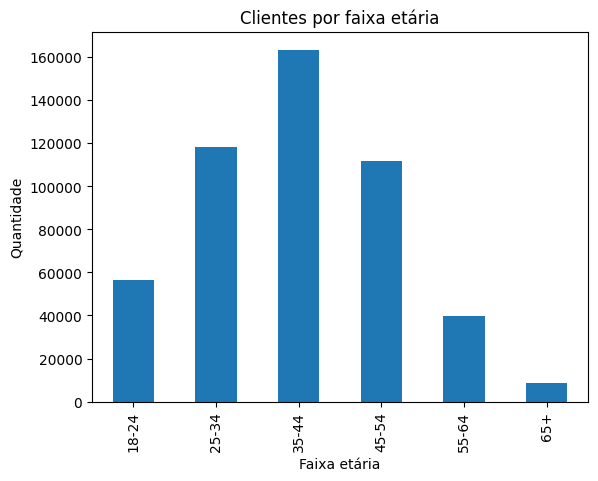

In [20]:
vendas["FAIXA_ETARIA"].value_counts().sort_index().plot(kind="bar")
plt.title("Clientes por faixa etária")
plt.xlabel("Faixa etária")
plt.ylabel("Quantidade")
plt.show()


In [21]:
vendas["ESTADO"].value_counts()


ESTADO
SÃO PAULO            160883
RIO DE JANEIRO        88936
PARANÁ                69714
BAHIA                 59254
RIO GRANDE DO SUL     49970
SANTA CATARINA        49855
PARAÍBA               19801
Name: count, dtype: int64

A faixa de 35 a 44 anos aparece bastante na base.
Também é possível ver que São Paulo possui mais registros que os outros estados.


## categorias de produtos


In [22]:
# faturamento por categoria
faturamento_categoria = vendas.groupby("CATEGORIA")["VALOR_TOTAL"].sum().sort_values(ascending=False)
faturamento_categoria


CATEGORIA
JARDINAGEM                 999400100
UTILIDADES DOMÉSTICAS      915142005
LIMPEZA                    483704730
MANGUEIRAS                 445981095
MAQUINA DE CORTAR GRAMA    162129850
Name: VALOR_TOTAL, dtype: int64

In [23]:
# quantidade vendida
volume_categoria = vendas.groupby("CATEGORIA")["QUANTIDADE_VENDIDA"].sum().sort_values(ascending=False)
volume_categoria


CATEGORIA
MANGUEIRAS                 29732073
UTILIDADES DOMÉSTICAS      20336489
JARDINAGEM                 19988002
LIMPEZA                    16123491
MAQUINA DE CORTAR GRAMA     6485194
Name: QUANTIDADE_VENDIDA, dtype: int64

In [24]:
# ticket médio simples
ticket_categoria = vendas.groupby("CATEGORIA")["VALOR_TOTAL"].mean().sort_values(ascending=False)
ticket_categoria


CATEGORIA
JARDINAGEM                 10047.150426
UTILIDADES DOMÉSTICAS       9139.812488
LIMPEZA                     4849.559163
MANGUEIRAS                  4491.475855
MAQUINA DE CORTAR GRAMA     1624.905791
Name: VALOR_TOTAL, dtype: float64

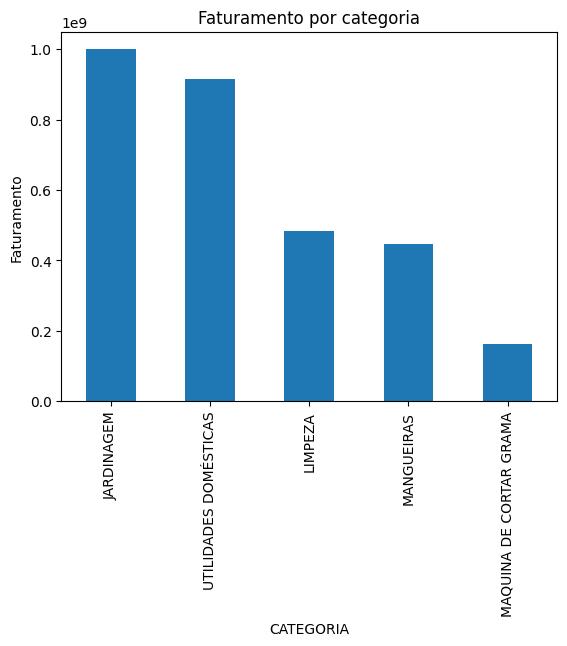

In [25]:
faturamento_categoria.plot(kind="bar")
plt.title("Faturamento por categoria")
plt.ylabel("Faturamento")
plt.show()


Pelo faturamento, algumas categorias ficam bem próximas.
Jardinagem aparece entre as categorias de maior faturamento e Mangueiras tem bastante volume vendido.


## vendas ao longo do tempo


In [26]:
# pegando mês e ano
vendas["MES"] = vendas["DATA"].dt.month
vendas["ANO"] = vendas["DATA"].dt.year


In [27]:
faturamento_mes = vendas.groupby("MES")["VALOR_TOTAL"].sum()
faturamento_mes


MES
1     275901415
2     242516565
3     268223500
4     223350045
5     233061355
6     226079040
7     240824865
8     232302790
9     257568805
10    267143230
11    264722900
12    274663270
Name: VALOR_TOTAL, dtype: int64

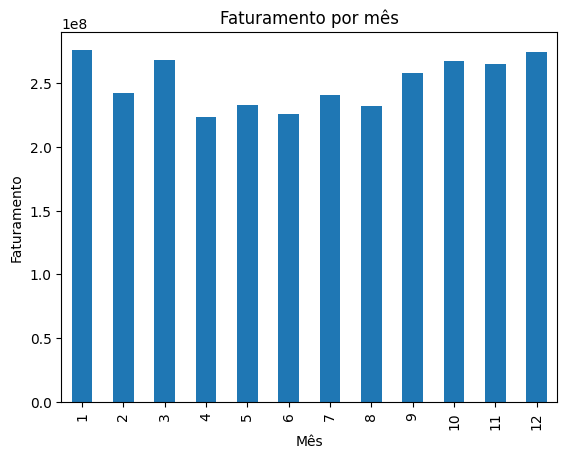

In [28]:
faturamento_mes.plot(kind="bar")
plt.title("Faturamento por mês")
plt.xlabel("Mês")
plt.ylabel("Faturamento")
plt.show()


In [29]:
vendas.groupby("ANO")["VALOR_TOTAL"].sum()


ANO
2021    598243100
2022    601919305
2023    601202555
2024    603771885
2025    601220935
Name: VALOR_TOTAL, dtype: int64

Os meses possuem algumas diferenças, mas no geral não parece existir uma sazonalidade muito forte só olhando esse gráfico.


## análise por estado


In [30]:
faturamento_estado = vendas.groupby("ESTADO")["VALOR_TOTAL"].sum().sort_values(ascending=False)
faturamento_estado


ESTADO
SÃO PAULO            1029054630
RIO DE JANEIRO        550350305
PARANÁ                407076280
BAHIA                 331398770
SANTA CATARINA        295674025
RIO GRANDE DO SUL     287600490
PARAÍBA               105203280
Name: VALOR_TOTAL, dtype: int64

In [31]:
volume_estado = vendas.groupby("ESTADO")["QUANTIDADE_VENDIDA"].sum().sort_values(ascending=False)
volume_estado


ESTADO
SÃO PAULO            31771227
RIO DE JANEIRO       16961318
PARANÁ               12544260
BAHIA                10240620
SANTA CATARINA        9073582
RIO GRANDE DO SUL     8831991
PARAÍBA               3242251
Name: QUANTIDADE_VENDIDA, dtype: int64

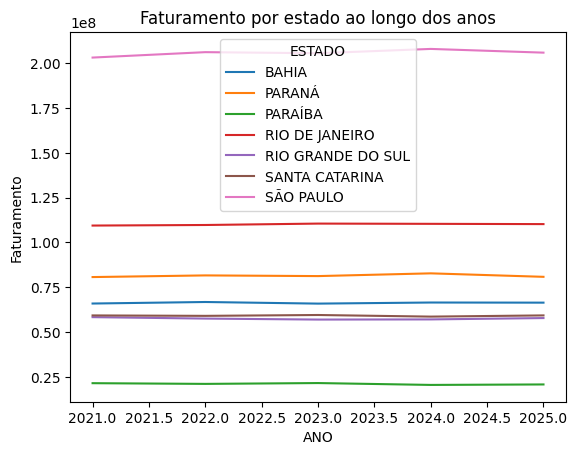

In [32]:
vendas.groupby(["ANO", "ESTADO"])["VALOR_TOTAL"].sum().unstack().plot()
plt.title("Faturamento por estado ao longo dos anos")
plt.ylabel("Faturamento")
plt.show()


São Paulo apresenta o maior faturamento.
No gráfico por ano, os estados seguem um comportamento relativamente parecido.


## idade e categoria


In [33]:
idade_categoria = vendas.groupby(
    ["FAIXA_ETARIA", "CATEGORIA"]
)["QUANTIDADE_VENDIDA"].sum()

idade_categoria


FAIXA_ETARIA  CATEGORIA              
18-24         JARDINAGEM                 2172966
              LIMPEZA                    1736506
              MANGUEIRAS                 3198491
              MAQUINA DE CORTAR GRAMA     695237
              UTILIDADES DOMÉSTICAS      2223585
25-34         JARDINAGEM                 4645436
              LIMPEZA                    3733632
              MANGUEIRAS                 6917042
              MAQUINA DE CORTAR GRAMA    1503598
              UTILIDADES DOMÉSTICAS      4723672
35-44         JARDINAGEM                 6553677
              LIMPEZA                    5290873
              MANGUEIRAS                 9749016
              MAQUINA DE CORTAR GRAMA    2127083
              UTILIDADES DOMÉSTICAS      6683053
45-54         JARDINAGEM                 4576169
              LIMPEZA                    3700714
              MANGUEIRAS                 6848526
              MAQUINA DE CORTAR GRAMA    1493621
              UTILIDADES DOMÉST

In [34]:
tabela_idade_categoria = idade_categoria.unstack()
tabela_idade_categoria


CATEGORIA,JARDINAGEM,LIMPEZA,MANGUEIRAS,MAQUINA DE CORTAR GRAMA,UTILIDADES DOMÉSTICAS
FAIXA_ETARIA,,,,,
18-24,2172966,1736506,3198491,695237,2223585
25-34,4645436,3733632,6917042,1503598,4723672
35-44,6553677,5290873,9749016,2127083,6683053
45-54,4576169,3700714,6848526,1493621,4624155
55-64,1671469,1361778,2460979,544593,1709311
65+,368285,299988,558019,121062,372713


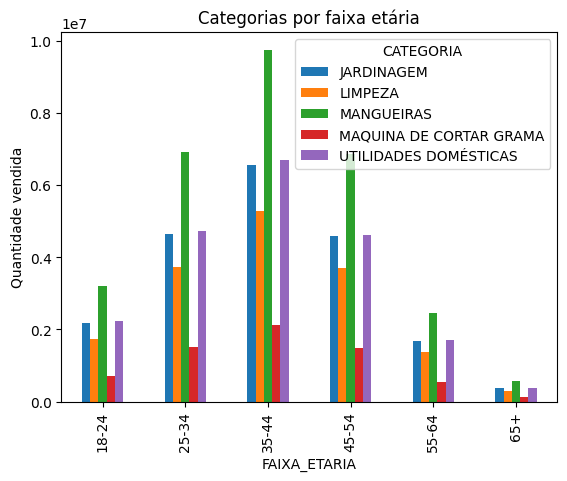

In [35]:
tabela_idade_categoria.plot(kind="bar")
plt.title("Categorias por faixa etária")
plt.ylabel("Quantidade vendida")
plt.show()


In [36]:
tabela_idade_categoria.idxmax(axis=1)


FAIXA_ETARIA
18-24    MANGUEIRAS
25-34    MANGUEIRAS
35-44    MANGUEIRAS
45-54    MANGUEIRAS
55-64    MANGUEIRAS
65+      MANGUEIRAS
dtype: str

## salvando a base tratada


In [37]:
vendas.to_csv("../vendas_tratadas.csv", index=False, sep=";")
